In [8]:
import pandas as pd

df = pd.read_csv("netflix_titles (1).csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [6]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [7]:
df['release_year'].value_counts().sort_index().tail(10)

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

In [8]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [9]:
df['director'].value_counts().head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

In [10]:
df[df['type'] == 'Movie']['duration'].str.replace(' min', '').astype(float).describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

EDA Summary — Netflix Movies & TV Shows

* Dataset: 8,807 titles, 12 columns

* Key Questions Explored:
1. What does the content mix look like (Movies vs TV Shows)?
2. Which countries and directors produce the most content?
3. How has content volume changed over time?
4. What are the most common genres?
5. What data quality issues exist?

* Key Findings:
1. Movies dominate the catalog (6,131) over TV Shows (2,676) — roughly 70/30 split
2. The United States (2,818 titles) and India (972) are by far the top content-producing countries
3. Content additions grew steadily, peaking in 2018 (1,147 titles), then declined — 2021 data is incomplete
4. Dramas and International Movies are the most common genre combinations
5. Rajiv Chilaka is the most prolific director (19 titles), alongside notable names like Martin Scorsese and Steven Spielberg
6. Data quality issues: director (2,634 missing), country (831 missing), cast (825 missing) — these are the main gaps to note
7. Average movie runtime is ~100 minutes, typical range 87–114 minutes

* Task 3: Data Visualization 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_style('whitegrid')
sns.set_context('talk')
plt.rcParams['font.family'] = 'Georgia'

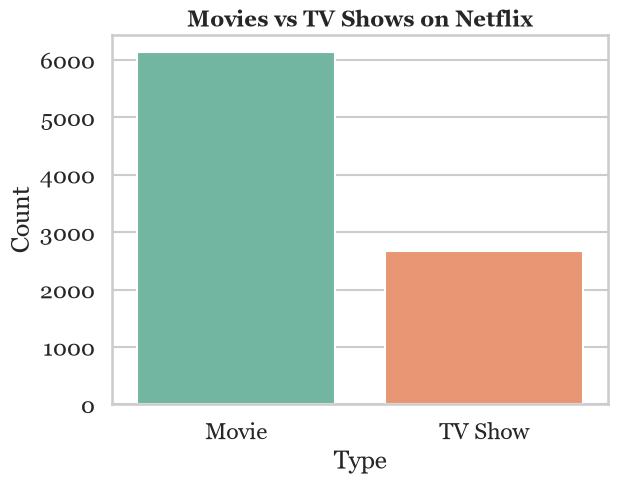

In [13]:
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

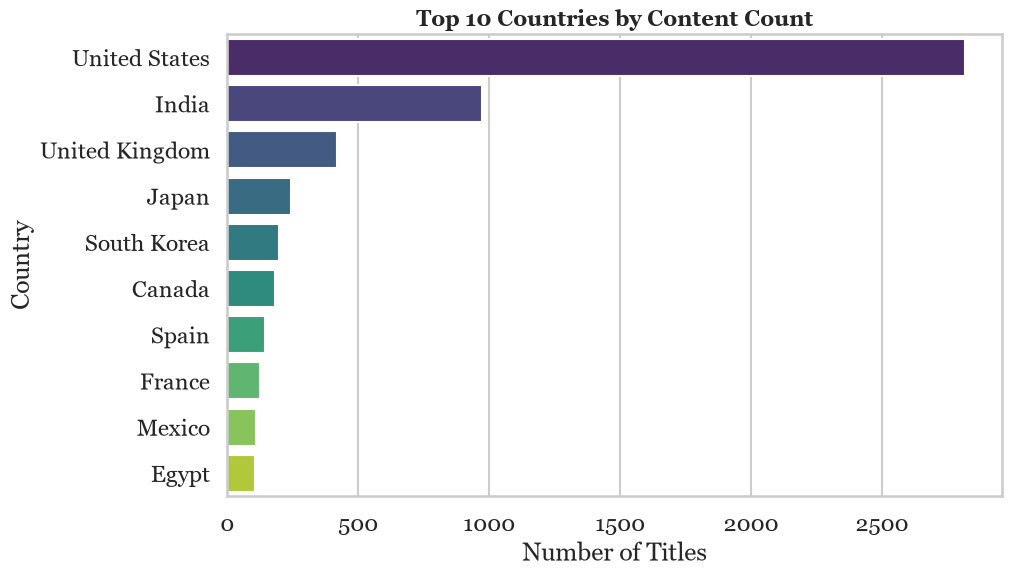

In [11]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Content Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

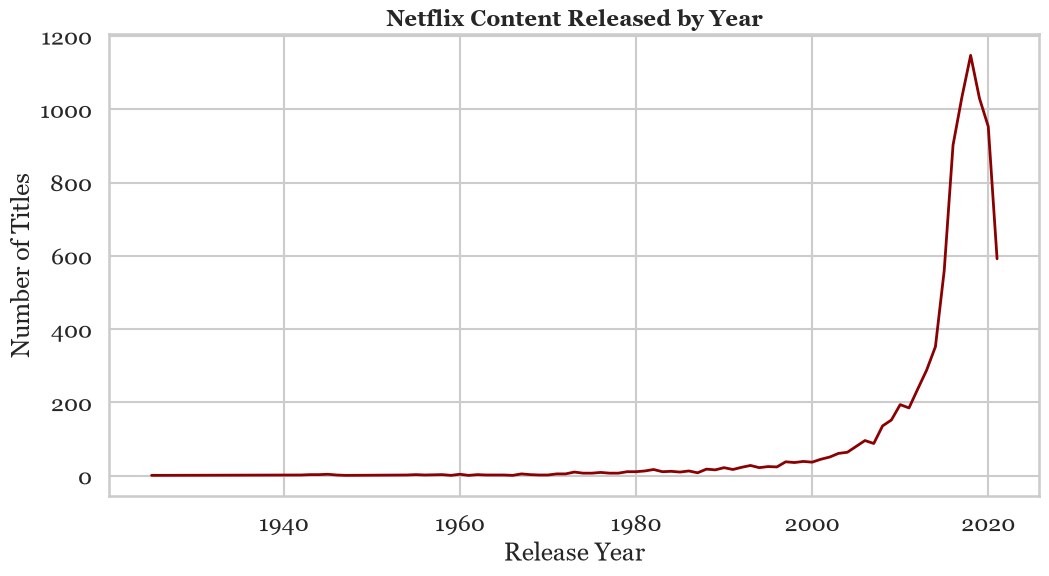

In [14]:
yearly = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=yearly.index, y=yearly.values, color='darkred', linewidth=2)
plt.title('Netflix Content Released by Year', fontsize=16, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

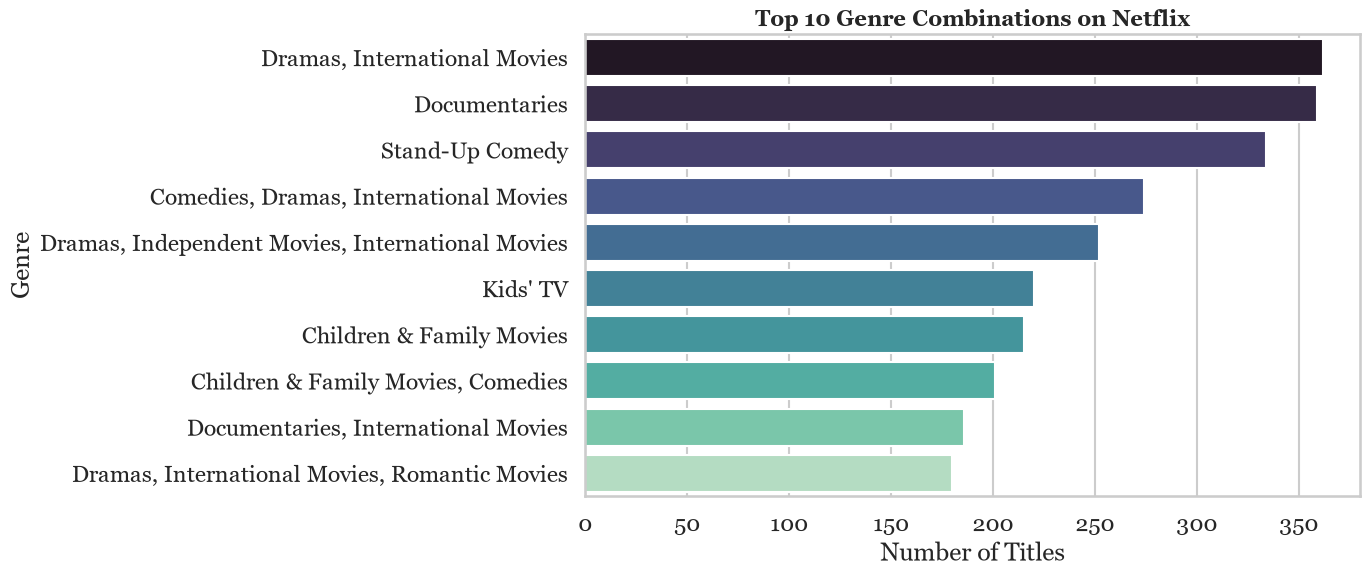

In [15]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='mako', legend=False)
plt.title('Top 10 Genre Combinations on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

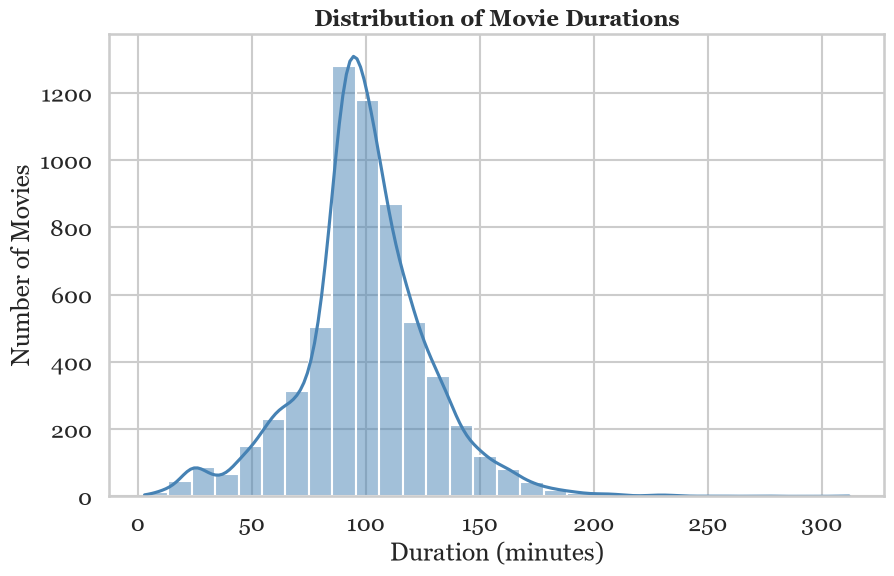

In [16]:
movie_durations = df[df['type'] == 'Movie']['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(10,6))
sns.histplot(movie_durations, bins=30, color='steelblue', kde=True)
plt.title('Distribution of Movie Durations', fontsize=16, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

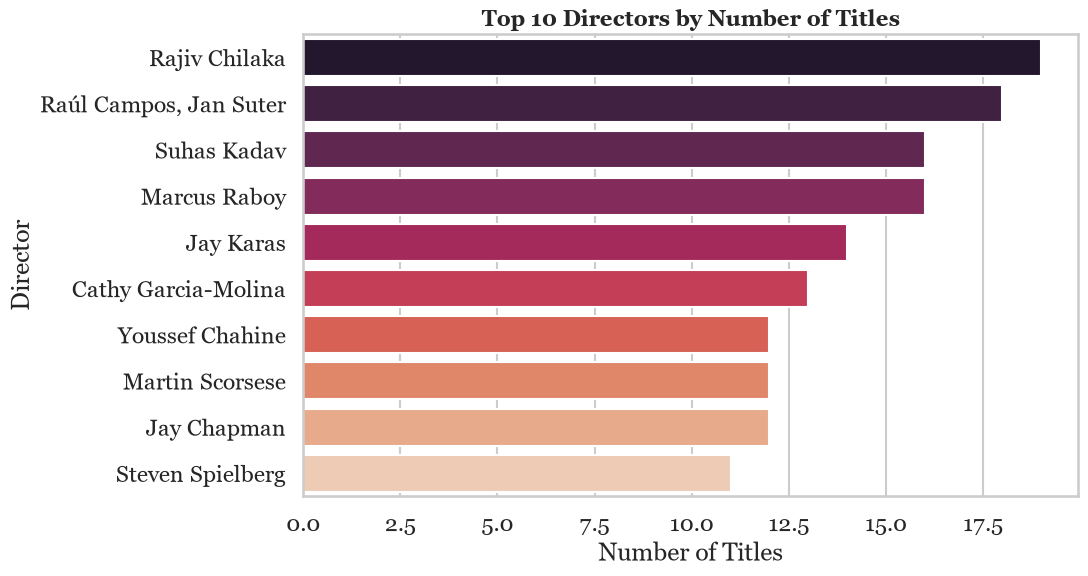

In [18]:
top_directors = df['director'].dropna().value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, palette='rocket', legend=False)
plt.title('Top 10 Directors by Number of Titles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

* Task 3 Summary — What I Found

* I made 6 pictures (charts) to show what's inside the Netflix data:

1. Netflix has more movies than TV shows
2. The USA and India make the most Netflix content
3. Netflix started adding a lot more shows and movies after 2015
4. Stand-up comedy is the most common type of show on Netflix
5. Most movies are between 90 and 110 minutes long
6. A few directors have more titles than others, but no one director has too many

* These pictures make it easy to see what we found in the data.

* Task 4: Sentiment Analysis

In [19]:
!pip install textblob

  Using cached textblob-0.20.1-py3-none-any.whl.metadata (4.0 kB)
Using cached textblob-0.20.1-py3-none-any.whl (624 kB)


In [20]:
from textblob import TextBlob

sample = df['description'][0]
print(sample)

blob = TextBlob(sample)
print(blob.sentiment)

As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.
Sentiment(polarity=0.3333333333333333, subjectivity=1.0)


In [21]:
df['polarity'] = df['description'].apply(lambda x: TextBlob(x).sentiment.polarity)
df[['title', 'description', 'polarity']].head()

,title,description,polarity
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",0.333333
1,Blood & Water,"After crossing paths at a party, a Cape Town t...",0.000000
2,Ganglands,To protect his family from a powerful drug lor...,-0.050000
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",-0.030505
4,Kota Factory,In a city of coaching centers known to train I...,0.000000


In [22]:
def get_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['polarity'].apply(get_sentiment)
df['sentiment'].value_counts()

sentiment
Positive    4547
Negative    2662
Neutral     1598
Name: count, dtype: int64

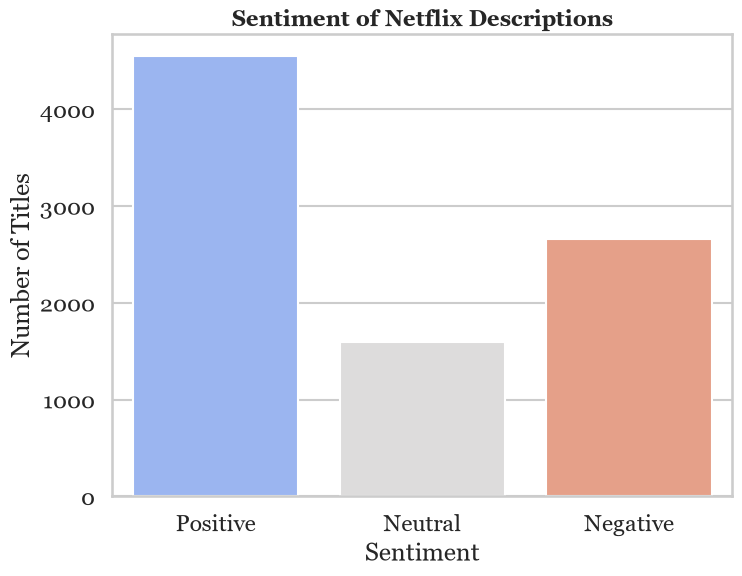

In [24]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='coolwarm', legend=False, order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment of Netflix Descriptions', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Titles')
plt.show()

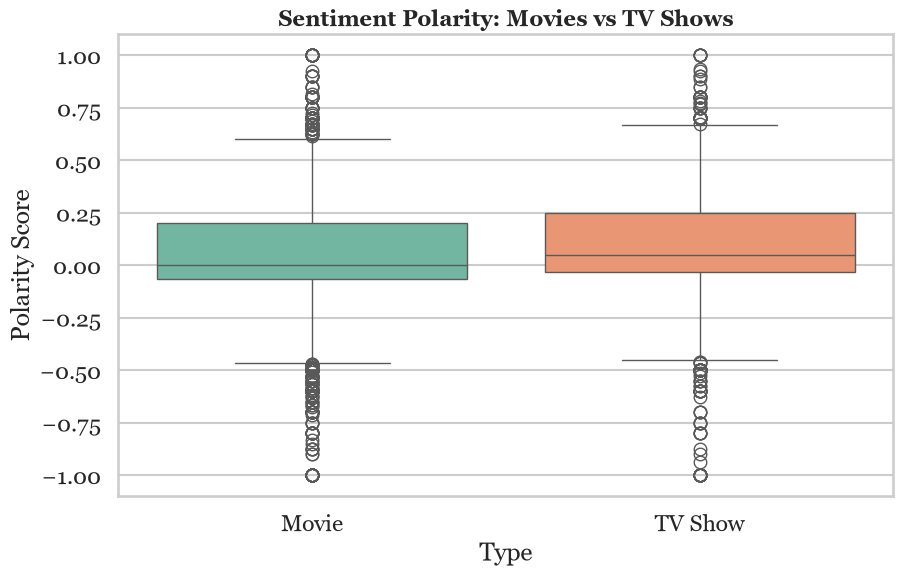

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='type', y='polarity', hue='type', palette='Set2', legend=False)
plt.title('Sentiment Polarity: Movies vs TV Shows', fontsize=16, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Polarity Score')
plt.show()

* Task 4 Summary — What I Found

I checked the descriptions of every movie and show to see if they sound positive, negative, or neutral:

1. Most descriptions sound positive (about half of them)
2. Some sound negative, and fewer sound neutral (plain, no strong feeling)
3. Movies and TV shows have almost the same mix of positive and negative descriptions — the type of content doesn't change the tone much

This shows that Netflix writes most of its descriptions to sound appealing, even for serious or dark shows.

* Business Insight:
    
  Since most Netflix descriptions are written to sound positive, this suggests Netflix's marketing team intentionally frames content even serious dramas or true crime in an appealing way to attract viewers. 
  This pattern could guide future product descriptions to maintain a consistently positive tone, which may improve click-through and viewership.